In [86]:
import pandas as pd

In [87]:
import seaborn as sns

In [88]:
import matplotlib.pyplot as plt

In [89]:
data = pd.read_csv("C:/Users/abass/OneDrive/Desktop/STATISTICAL TOOLS/PYTHON/Data/Category Values.csv")

In [90]:
print(data.head())

   OrderID   OrderDate CustomerID  Gender Department  StaffSalary  \
0     1001  01/05/2025       C001  Female      Sales        500.0   
1     1002  01/07/2025       C002    Male    Support        400.0   
2     1003  01/10/2025       C003  Female      Sales          NaN   
3     1004  01/12/2025       C004    Male  Marketing        600.0   
4     1005   1/15/2025       C005  Female      Sales        500.0   

  ProductCategory  Quantity  UnitPrice  Revenue  
0     Electronics         2        250      500  
1         Fashion         3         50      150  
2     Electronics         1        300      300  
3       Groceries        10         20      200  
4         Fashion         2         80      160  


In [91]:
print(data.tail())

   OrderID   OrderDate CustomerID  Gender Department  StaffSalary  \
5     1006   1/20/2025       C006    Male    Support        400.0   
6     1007   1/22/2025       C007  Female  Marketing        600.0   
7     1008   1/25/2025       C008    Male      Sales        500.0   
8     1009   1/28/2025       C009  Female    Support        400.0   
9     1010  02/01/2025       C010    Male      Sales        500.0   

  ProductCategory  Quantity  UnitPrice  Revenue  
5     Electronics         5        220     1100  
6         Fashion         1        100      100  
7       Groceries        20         15      300  
8         Fashion         2         60      120  
9     Electronics         1        500      500  


In [92]:
print(data.describe())

          OrderID  StaffSalary   Quantity   UnitPrice      Revenue
count    10.00000     9.000000  10.000000   10.000000    10.000000
mean   1005.50000   488.888889   4.700000  159.500000   343.000000
std       3.02765    78.173596   6.037844  156.212996   302.950308
min    1001.00000   400.000000   1.000000   15.000000   100.000000
25%    1003.25000   400.000000   1.250000   52.500000   152.500000
50%    1005.50000   500.000000   2.000000   90.000000   250.000000
75%    1007.75000   500.000000   4.500000  242.500000   450.000000
max    1010.00000   600.000000  20.000000  500.000000  1100.000000


In [93]:
## Handling missing values 
# Fill missing StaffSalary with the mean

data["StaffSalary"] = data["StaffSalary"].fillna(data["StaffSalary"].mean())
print(data["StaffSalary"])

0    500.000000
1    400.000000
2    488.888889
3    600.000000
4    500.000000
5    400.000000
6    600.000000
7    500.000000
8    400.000000
9    500.000000
Name: StaffSalary, dtype: float64


In [94]:
print(data.isna().sum())

OrderID            0
OrderDate          0
CustomerID         0
Gender             0
Department         0
StaffSalary        0
ProductCategory    0
Quantity           0
UnitPrice          0
Revenue            0
dtype: int64


In [95]:
## Convert OrderDate to datetime and extract Year, Month

data["OrderDate"] = pd.to_datetime(data["OrderDate"])
data["Year"] = data["OrderDate"].dt.year
data["Month"] = data["OrderDate"].dt.month

print(data[["OrderDate","Year","Month"]].head())

   OrderDate  Year  Month
0 2025-01-05  2025      1
1 2025-01-07  2025      1
2 2025-01-10  2025      1
3 2025-01-12  2025      1
4 2025-01-15  2025      1


In [96]:
## One-hot Encoding for categorical variables

data_encoded = pd.get_dummies(data, columns=["Gender","Department","ProductCategory"])
print("Data after encoding:")
print(data_encoded.head())


Data after encoding:
   OrderID  OrderDate CustomerID  StaffSalary  Quantity  UnitPrice  Revenue  \
0     1001 2025-01-05       C001   500.000000         2        250      500   
1     1002 2025-01-07       C002   400.000000         3         50      150   
2     1003 2025-01-10       C003   488.888889         1        300      300   
3     1004 2025-01-12       C004   600.000000        10         20      200   
4     1005 2025-01-15       C005   500.000000         2         80      160   

   Year  Month  Gender_Female  Gender_Male  Department_Marketing  \
0  2025      1           True        False                 False   
1  2025      1          False         True                 False   
2  2025      1           True        False                 False   
3  2025      1          False         True                  True   
4  2025      1           True        False                 False   

   Department_Sales  Department_Support  ProductCategory_Electronics  \
0              True    

In [97]:
print(data_encoded.tail())

   OrderID  OrderDate CustomerID  StaffSalary  Quantity  UnitPrice  Revenue  \
5     1006 2025-01-20       C006        400.0         5        220     1100   
6     1007 2025-01-22       C007        600.0         1        100      100   
7     1008 2025-01-25       C008        500.0        20         15      300   
8     1009 2025-01-28       C009        400.0         2         60      120   
9     1010 2025-02-01       C010        500.0         1        500      500   

   Year  Month  Gender_Female  Gender_Male  Department_Marketing  \
5  2025      1          False         True                 False   
6  2025      1           True        False                  True   
7  2025      1          False         True                 False   
8  2025      1           True        False                 False   
9  2025      2          False         True                 False   

   Department_Sales  Department_Support  ProductCategory_Electronics  \
5             False                True     

In [98]:
data_encoded = pd.get_dummies(data,columns=["Gender","Department","ProductCategory"], dtype=int)
print(data_encoded.head())

   OrderID  OrderDate CustomerID  StaffSalary  Quantity  UnitPrice  Revenue  \
0     1001 2025-01-05       C001   500.000000         2        250      500   
1     1002 2025-01-07       C002   400.000000         3         50      150   
2     1003 2025-01-10       C003   488.888889         1        300      300   
3     1004 2025-01-12       C004   600.000000        10         20      200   
4     1005 2025-01-15       C005   500.000000         2         80      160   

   Year  Month  Gender_Female  Gender_Male  Department_Marketing  \
0  2025      1              1            0                     0   
1  2025      1              0            1                     0   
2  2025      1              1            0                     0   
3  2025      1              0            1                     1   
4  2025      1              1            0                     0   

   Department_Sales  Department_Support  ProductCategory_Electronics  \
0                 1                   0     

In [99]:
## to see all new dummy columns
print(data_encoded.columns)

Index(['OrderID', 'OrderDate', 'CustomerID', 'StaffSalary', 'Quantity',
       'UnitPrice', 'Revenue', 'Year', 'Month', 'Gender_Female', 'Gender_Male',
       'Department_Marketing', 'Department_Sales', 'Department_Support',
       'ProductCategory_Electronics', 'ProductCategory_Fashion',
       'ProductCategory_Groceries'],
      dtype='object')


In [100]:
## Count how many dummy columns were created
print("Number of columns after encoding:", len(data_encoded.columns))

Number of columns after encoding: 17


In [101]:
## Group by department to show total Revenue

dept_revenue = data.groupby("Department")["Revenue"].sum()
print("Revenue by Department:")
print(dept_revenue)

Revenue by Department:
Department
Marketing     300
Sales        1760
Support      1370
Name: Revenue, dtype: int64


In [102]:
## Group by Month to show total Revenue

monthly_revenue = data.groupby("Month")["Revenue"].sum()
print("Revenue by Month")
print(monthly_revenue)

Revenue by Month
Month
1    2930
2     500
Name: Revenue, dtype: int64


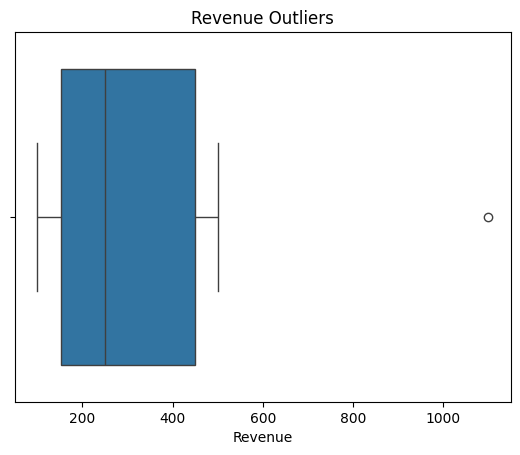

In [103]:
## Outlier detection with boxplot

sns.boxplot(x=data["Revenue"])
plt.title('Revenue Outliers')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

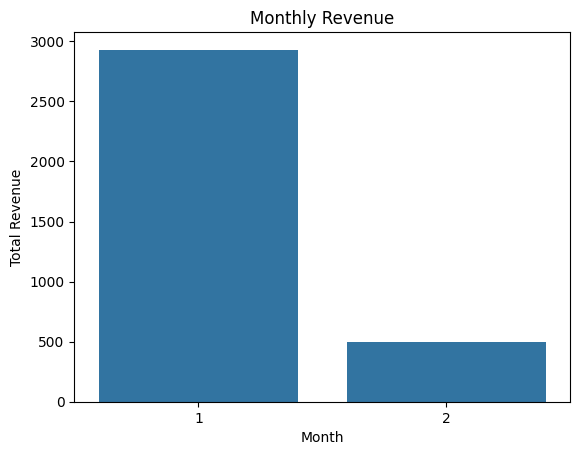

In [104]:
## Visualization of monthly revenue
sns.barplot(x=monthly_revenue.index, y=monthly_revenue.values)
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.show